# Imports

In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
import pandas as pd

# Conc Fns

In [25]:
def box_char_func_np(x, x0, x1, y0, y1, z0, z1):
    """
    Determines if points in a NumPy array are within a specified 3D box.

    Parameters:
    x (np.ndarray): A 2D NumPy array of shape (n, 3) where each row represents a point in 3D space.
    x0 (float): The minimum x-coordinate of the box.
    x1 (float): The maximum x-coordinate of the box.
    y0 (float): The minimum y-coordinate of the box.
    y1 (float): The maximum y-coordinate of the box.
    z0 (float): The minimum z-coordinate of the box.
    z1 (float): The maximum z-coordinate of the box.

    Returns:
    np.ndarray: A 1D boolean array of length n where each element is True if the corresponding point is within the box, and False otherwise.
    """
    return np.logical_and.reduce((x[:, 0] >= x0, x[:, 0] <= x1, x[:, 1] >= y0, x[:, 1] <= y1, x[:, 2] >= z0, x[:, 2] <= z1))


In [26]:
def unif_concentration(x, a):
    """
    Generates a uniform concentration array.

    Parameters:
    x (numpy.ndarray): An array whose shape will be used to determine the size of the output array.
    a (float): The value to fill the output array with.

    Returns:
    numpy.ndarray: An array of the same length as the first dimension of `x`, filled with the value `a`.
    """
    return np.full(x.shape[0], a)

In [27]:
def clip(x, min_val, max_val):
    """
    Clips (limits) the values in an array.

    Parameters:
    x (numpy.ndarray): The array to clip.
    min_val (float): The minimum value to allow in the array.
    max_val (float): The maximum value to allow in the array.

    Returns:
    numpy.ndarray: A new array clipped so that all values are between `min_val` and `max_val`.
    """
    return np.clip(x, min_val, max_val)

In [28]:
def vertical_linear_gradient_dist(x, z_0, z_1, c_0, c_1):
    """
    Generates a linear gradient in the vertical direction.

    Parameters:
    x (numpy.ndarray): A 2D NumPy array of shape (n, 3) where each row represents a point in 3D space.
    z_0 (float): The minimum z-coordinate of the gradient.
    z_1 (float): The maximum z-coordinate of the gradient.
    c_0 (float): The value of the gradient at z=z_0.
    c_1 (float): The value of the gradient at z=z_1.

    Returns:
    numpy.ndarray: An array of length n with the gradient values.
    """
    _ = c_0 + (c_1 - c_0) * (x[:, 2] - z_0) / (z_1 - z_0)
    return np.clip(_, c_0, c_1)
    return _

In [29]:
def radial_linear_gradient_dist(x, r_0, r_1, c_0, c_1):
    """
    Generates a linear gradient in the radial direction.

    Parameters:
    x (numpy.ndarray): A 2D NumPy array of shape (n, 3) where each row represents a point in 3D space.
    r_0 (float): The minimum radial distance of the gradient.
    r_1 (float): The maximum radial distance of the gradient.
    c_0 (float): The value of the gradient at r=r_0.
    c_1 (float): The value of the gradient at r=r_1.

    Returns:
    numpy.ndarray: An array of length n with the gradient values.
    """
    r = np.linalg.norm(x[:, :2], axis=1)
    _ = c_0 + (c_1 - c_0) * (r - r_0) / (r_1 - r_0)
    return np.clip(_, min([c_0, c_1]), max([c_0, c_1]))

In [30]:
def y_linear_gradient(x, y_0, y_1, c_0, c_1):
    """
    Generates a linear gradient in the y direction.

    Parameters:
    x (numpy.ndarray): A 2D NumPy array of shape (n, 3) where each row represents a point in 3D space.
    y_0 (float): The minimum y-coordinate of the gradient.
    y_1 (float): The maximum y-coordinate of the gradient.
    c_0 (float): The value of the gradient at y=y_0.
    c_1 (float): The value of the gradient at y=y_1.

    Returns:
    numpy.ndarray: An array of length n with the gradient values.
    """
    _ = c_0 + (c_1 - c_0) * (x[:, 1] - y_0) / (y_1 - y_0)
    return np.clip(_, c_0, c_1)

# Slice inspection

In [31]:
def xy_slice_inspect(ax, conc_func, x0, x1, y0, y1, z=.5, n=100, v_min=0, v_max=1):
    """
    Generate and graph a vertical slice of a 3D function.

    Parameters:
    x0 (float): The minimum x-coordinate of the slice.
    x1 (float): The maximum x-coordinate of the slice.
    y0 (float): The minimum y-coordinate of the slice.
    y1 (float): The maximum y-coordinate of the slice.
    z (float): The z-coordinate of the slice.
    n (int): The number of points to sample in the x and y directions.

    Returns:
    numpy.ndarray: A 2D array of shape (n, n) where each element is the value of the function at that point in the slice.
    """

    x = np.linspace(x0, x1, n)
    y = np.linspace(y0, y1, n)
    xx, yy = np.meshgrid(x, y)
    zz = np.full_like(xx, z)
    points = np.column_stack((xx.flatten(), yy.flatten(), zz.flatten()))
    conc = conc_func(points)
    conc = conc.reshape(n, n)

    contourf = ax.contourf(xx, yy, conc, levels=20, cmap='viridis', alpha=0.5, vmin=v_min, vmax=v_max)

    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect('equal')
    
    return contourf, conc

In [32]:
def yz_slice_inspect(ax, conc_func, y0, y1, z0, z1, x=.5, n=100, v_min=0, v_max=1):
    """
    Generate and graph a vertical slice of a 3D function.

    Parameters:
    y0 (float): The minimum y-coordinate of the slice.
    y1 (float): The maximum y-coordinate of the slice.
    z0 (float): The minimum z-coordinate of the slice.
    z1 (float): The maximum z-coordinate of the slice.
    x (float): The x-coordinate of the slice.
    n (int): The number of points to sample in the y and z directions.

    Returns:
    numpy.ndarray: A 2D array of shape (n, n) where each element is the value of the function at that point in the slice.
    """

    y = np.linspace(y0, y1, n)
    z = np.linspace(z0, z1, n)
    yy, zz = np.meshgrid(y, z)
    xx = np.full_like(yy, x)
    points = np.column_stack((xx.flatten(), yy.flatten(), zz.flatten()))
    conc = conc_func(points)
    conc = conc.reshape(n, n)

    contourf = ax.contourf(yy, zz, conc, levels=20, cmap='viridis', alpha=0.5, vmin=v_min, vmax=v_max)

    ax.set_xlim(y0, y1)
    ax.set_ylim(z0, z1)
    ax.set_aspect('equal')
    
    return contourf, conc

In [33]:
def xz_slice_inspect(ax, conc_func, x0, x1, z0, z1, y=.5, n=100, v_min=0, v_max=1):
    """
    Generate and graph a vertical slice of a 3D function.

    Parameters:
    x0 (float): The minimum x-coordinate of the slice.
    x1 (float): The maximum x-coordinate of the slice.
    z0 (float): The minimum z-coordinate of the slice.
    z1 (float): The maximum z-coordinate of the slice.
    y (float): The y-coordinate of the slice.
    n (int): The number of points to sample in the x and z directions.

    Returns:
    numpy.ndarray: A 2D array of shape (n, n) where each element is the value of the function at that point in the slice.
    """

    x = np.linspace(x0, x1, n)
    z = np.linspace(z0, z1, n)
    xx, zz = np.meshgrid(x, z)
    yy = np.full_like(xx, y)
    points = np.column_stack((xx.flatten(), yy.flatten(), zz.flatten()))
    conc = conc_func(points)
    conc = conc.reshape(n, n)

    contourf = ax.contourf(xx, zz, conc, levels=20, cmap='viridis', alpha=0.5, vmin=v_min, vmax=v_max)

    ax.set_xlim(x0, x1)
    ax.set_ylim(z0, z1)
    ax.set_aspect('equal')
    
    return contourf, conc

# Example

# Remaining chemicals

In [34]:
c0_compposition = {6000: -0.2700, 1001: -0.0075, 14000: -0.3092, 8016: -0.4133}
c1_compposition = {6000: -0.1870, 1001: -0.0052, 14000: -0.3576, 8016: -0.4502}
c2_compposition = {6000: -0.1150, 1001: -0.0032, 14000: -0.3996, 8016: -0.4822}
c3_compposition = {6000: -0.0532, 1001: -0.0015, 14000: -0.4356, 8016: -0.5097}
c4_compposition = {6000: -0.0258, 1001: -0.0007, 14000: -0.4516, 8016: -0.5219}
c5_compposition = {6000: -0.0001, 1001: -0.0001, 14000: -0.4666, 8016: -0.5332}

compositions = [c0_compposition, c1_compposition, c2_compposition, c3_compposition, c4_compposition, c5_compposition]
df = pd.DataFrame(compositions)

In [35]:
df

,6000,1001,14000,8016
0,-0.2700,-0.0075,-0.3092,-0.4133
1,-0.1870,-0.0052,-0.3576,-0.4502
2,-0.1150,-0.0032,-0.3996,-0.4822
3,-0.0532,-0.0015,-0.4356,-0.5097
4,-0.0258,-0.0007,-0.4516,-0.5219
5,-0.0001,-0.0001,-0.4666,-0.5332


In [36]:
ids = [14000, 8016, 1001]
rel_portions = [0.44, 0.55, 0.01]

# below gets relative portions of the remaining elements keeping them proportional to the remaining weight
def bandaid_get_elems(x, f, rel_portions, round_to=8): 
    out = {}
    out = np.zeros((x.shape[0], len(rel_portions)+1))
    c = f(x)
    out[:, 0] = -c
    for i, port in enumerate(rel_portions):
        out[:, i+1] = -(1-c)*port
    out = np.round(out, round_to)

    return out

x = np.array([[0, 0, 0], [0, 1, 1]])
f = lambda x: radial_linear_gradient_dist(x, 0, 1.5, .5, .2)
print(bandaid_get_elems(x, f, rel_portions))

[[-0.5   -0.22  -0.275 -0.005]
 [-0.3   -0.308 -0.385 -0.007]]


In [37]:
soil_x0 = -1
soil_x1 = 1
soil_y0 = -1
soil_y1 = 1
soil_z0 = -2
soil_z1 = 0

v_min = 0.05 # Minimum value for the concentration for plotting
v_max = 0.25 # Maximum value for the concentration for plotting

# conc_func = lambda x: radial_linear_gradient_dist(x, 0, 1.5, v_max, v_min)
conc_func = lambda x: vertical_linear_gradient_dist(x, soil_z0, soil_z1, v_min, v_max)
# conc_func = lambda x: unif_concentration(x, v_max)
# conc_func = lambda x: y_linear_gradient(x, soil_y0, soil_y1, v_min, v_max)


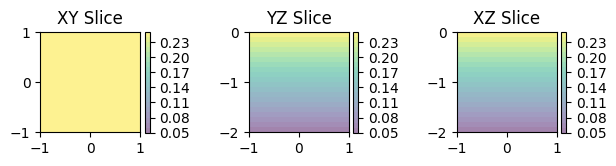

In [38]:
fig = plt.figure()
axs = [fig.add_subplot(131), fig.add_subplot(132), fig.add_subplot(133)]
xy_contf, xy_conc = xy_slice_inspect(axs[0], conc_func, soil_x0, soil_x1, soil_y0, soil_y1, soil_z1, 100, v_min, v_max)
axs[0].set_title('XY Slice')
yz_contf, yz_conc = yz_slice_inspect(axs[1], conc_func, soil_y0, soil_y1, soil_z0, soil_z1, 0, 100, v_min, v_max)
axs[1].set_title('YZ Slice')
xz_contf, xz_conc = xz_slice_inspect(axs[2], conc_func, soil_x0, soil_x1, soil_z0, soil_z1, 0, 100, v_min, v_max)
axs[2].set_title('XZ Slice')

contfs = [xy_contf, yz_contf, xz_contf]
for ax in axs:
    fig.colorbar(contfs[1], ax=ax, fraction=0.046, pad=0.04, boundaries=np.linspace(v_min, v_max, 100))
plt.tight_layout()

plt.show()

In [39]:
# this keeps it to mcnp standards (sum must be 1)
def force_n_digits(x, n):
    # if x is less that 10^n, return 0000...x such that the length is n digits, else return x
    if x < 10**n:
        return f'{x:0{n}d}'
    return f'{x}'
# print(force_n_digits(100, 2))

In [40]:
def make_mcnp(extent, res, f, noncarbon_rel_portions, noncarbon_labels, surface_header = '', surface_footer= '', mat_header = '', mat_footer='', cell_header= '', cell_footer= ''):
    x0, x1, y0, y1, z0, z1 = extent
    x_res, y_res, z_res = res
    xs = np.linspace(x0, x1, x_res+1)
    ys = np.linspace(y0, y1, y_res+1)
    zs = np.linspace(z0, z1, z_res+1)

    n = int(np.ceil(np.log10(max(x_res+1, y_res+1, z_res+1))))
    surfaces = ''
    x_ids = []
    y_ids = []
    z_ids = []
    for i, x in enumerate(xs):
        surface_id = f'{surface_header}1{force_n_digits(i, n)}{surface_footer}'
        x_ids.append(surface_id)
        surfaces += (f'{int(surface_id)} px {x}\n')
    for i, y in enumerate(ys):
        surface_id = f'{surface_header}2{force_n_digits(i, n)}{surface_footer}'
        y_ids.append(surface_id)
        surfaces += (f'{int(surface_id)} py {y}\n')
    for i, z in enumerate(zs):
        surface_id = f'{surface_header}3{force_n_digits(i, n)}{surface_footer}'
        z_ids.append(surface_id)
        surfaces += (f'{int(surface_id)} pz {z}\n')

    xs = xs+(x1-x0)/x_res
    ys = ys+(y1-y0)/y_res
    zs = zs+(z1-z0)/z_res
    
    xx, yy, zz = np.meshgrid(xs[:-1], ys[:-1], zs[:-1])
    xx_index, yy_index, zz_index = np.meshgrid(x_ids[:-1], y_ids[:-1], z_ids[:-1])
    xx_index, yy_index, zz_index = xx_index.flatten(), yy_index.flatten(), zz_index.flatten()
    xl_ids, yl_ids, zl_ids = x_ids[1:], y_ids[1:], z_ids[1:]
    xxl_index, yyl_index, zzl_index = np.meshgrid(xl_ids, yl_ids, zl_ids)
    xxl_index, yyl_index, zzl_index = xxl_index.flatten(), yyl_index.flatten(), zzl_index.flatten()
    points = np.column_stack((xx.flatten(), yy.flatten(), zz.flatten()))
    elems = bandaid_get_elems(points, f, noncarbon_rel_portions, 10)
    mats = ''
    nn = int(np.ceil(np.log10(len(elems))))
    elem_ids = []
    for i, elem in enumerate(elems):
        elem_id = f'{mat_header}{force_n_digits(i, nn)}{mat_footer}'
        elem_ids.append(elem_id)
        mats += f'm{elem_id} '
        for id, e in zip(['6000']+noncarbon_labels, elem):
            mats += f'{id} {e} '
        mats += '\n'

    cells = ''
    density = -1.05
    cell_ids = []
    for i, e in enumerate(elem_ids):
        cell_id = f'{cell_header}{force_n_digits(i, nn)}{cell_footer}'
        cell_ids.append(cell_id)
        cells += f'{cell_id} {e} {density} {xx_index[i]} -{xxl_index[i]} {yy_index[i]} -{yyl_index[i]} {zz_index[i]} -{zzl_index[i]} imp:n,p,e 1\n'
        
    return cells, cell_ids, surfaces, mats

In [41]:
# example
extent = (-1, 1, -1, 1, -2, 0) # x0, x1, y0, y1, z0, z1 min(0) and max(1) of the grid
res = (2, 2, 2) # number of cells in each direction


noncarbon_rel_portions = [0.44, 0.55, 0.01] # relative portions of the noncarbon elements
noncarbon_labels = ['14000', '8016', '1001'] # labels of the noncarbon elements

# below is used to assign the surface, material, and cell ids
surface_header = '1' #puts a 1 before the surface id
surface_footer = ''
mat_header = '2'
mat_footer = ''
cell_header = '3'
cell_footer = ''


example_cells, example_cell_ids, example_surfaces, example_materials = (make_mcnp(extent, res, conc_func, noncarbon_rel_portions, noncarbon_labels, surface_header, surface_footer, mat_header, mat_footer, cell_header, cell_footer))


In [42]:
print(example_cells)

30 20 -1.05 110 -111 120 -121 130 -131 imp:n,p,e 1
31 21 -1.05 110 -111 120 -121 131 -132 imp:n,p,e 1
32 22 -1.05 111 -112 120 -121 130 -131 imp:n,p,e 1
33 23 -1.05 111 -112 120 -121 131 -132 imp:n,p,e 1
34 24 -1.05 110 -111 121 -122 130 -131 imp:n,p,e 1
35 25 -1.05 110 -111 121 -122 131 -132 imp:n,p,e 1
36 26 -1.05 111 -112 121 -122 130 -131 imp:n,p,e 1
37 27 -1.05 111 -112 121 -122 131 -132 imp:n,p,e 1



In [45]:
example_cell_ids

['30', '31', '32', '33', '34', '35', '36', '37']

In [43]:
print(example_surfaces)

110 px -1.0
111 px 0.0
112 px 1.0
120 py -1.0
121 py 0.0
122 py 1.0
130 pz -2.0
131 pz -1.0
132 pz 0.0



In [44]:
print(example_materials)

m20 6000 -0.15 14000 -0.374 8016 -0.4675 1001 -0.0085 
m21 6000 -0.25 14000 -0.33 8016 -0.4125 1001 -0.0075 
m22 6000 -0.15 14000 -0.374 8016 -0.4675 1001 -0.0085 
m23 6000 -0.25 14000 -0.33 8016 -0.4125 1001 -0.0075 
m24 6000 -0.15 14000 -0.374 8016 -0.4675 1001 -0.0085 
m25 6000 -0.25 14000 -0.33 8016 -0.4125 1001 -0.0075 
m26 6000 -0.15 14000 -0.374 8016 -0.4675 1001 -0.0085 
m27 6000 -0.25 14000 -0.33 8016 -0.4125 1001 -0.0075 

